In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import statistics as st

import functools as ft

import scipy as sc
from scipy.stats import norm
from scipy.signal import welch

import cartopy.crs as ccrs

from eofs.xarray import Eof



In [28]:
path_name = './data/mslp.mon.mean.nc' 
ds = xr.open_dataset(path_name, decode_timedelta=True)


darwin = ds.sel(lat=slice(-7.5,-12.5)).sel(lon=slice(127.5,132,5)).mean(dim=("lat", "lon"))
tahiti = ds.sel(lat=slice(-12.5,-17.5)).sel(lon=slice(145,150)).mean(dim=("lat", "lon"))

# remove the mean 

darwin = darwin.mslp.groupby("time.month") - darwin.mslp.groupby("time.month").mean("time")
tahiti = tahiti.mslp.groupby("time.month") - tahiti.mslp.groupby("time.month").mean("time")

# standardise 

darwin = darwin / darwin.std(dim="time")
tahiti  = tahiti / tahiti.std(dim="time")


elnino = xr.concat([darwin, tahiti], dim="space")
elnino = elnino.transpose("time", "space")

elnino["space"] = ["Darwin", "Tahiti"]




In [30]:

solver = Eof(elnino)

eofs = solver.eofs(neofs=2)
pcs = solver.pcs(npcs=2, pcscaling=1)
variance = solver.varianceFraction()

In [31]:
print(eofs)

<xarray.DataArray 'eofs' (mode: 2, space: 2)> Size: 16B
array([[-0.70710677, -0.70710677],
       [-0.70710677,  0.70710677]], dtype=float32)
Coordinates:
  * mode     (mode) int64 16B 0 1
  * space    (space) <U6 48B 'Darwin' 'Tahiti'
Attributes:
    long_name:  empirical_orthogonal_functions


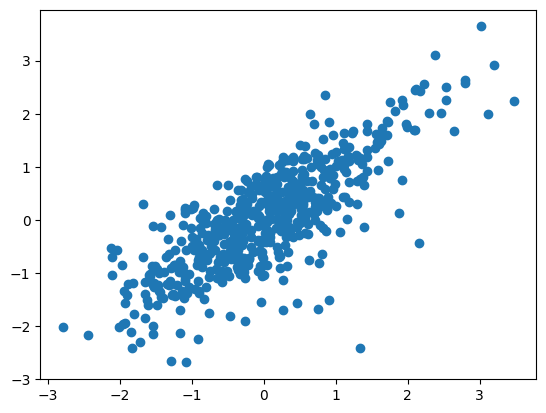

In [42]:
plt.scatter(darwin, tahiti)
plt.savefig('darwin-tahiti-scatter.pdf')

In [34]:
np.correlate(darwin, tahiti)

array([449.29935], dtype=float32)

In [37]:
print(np.corrcoef(darwin,tahiti))

[[1.         0.79662999]
 [0.79662999 1.        ]]


In [46]:
pcs[:,1]

<xarray.DataArray 'pcs' (time: 564)> Size: 2kB
array([-3.81530094e+00, -4.17080641e-01, -1.27845600e-01, -3.33787084e-01,
        1.22662950e+00,  6.00275755e-01,  3.64890724e-01,  1.29510224e+00,
        1.80835712e+00, -4.88639534e-01,  1.04849339e+00, -2.42944211e-01,
        9.54672575e-01, -7.05141783e-01, -4.66982871e-01,  1.55251825e+00,
        2.73493797e-01,  9.88508403e-01, -1.73865613e-02,  1.24724376e+00,
        9.10184205e-01,  1.02089100e-01,  2.10400149e-01,  8.17825675e-01,
        1.50069845e+00, -3.07712984e+00,  5.25521338e-01, -8.83505642e-01,
        6.62399769e-01, -1.77090272e-01,  1.04288089e+00,  8.31207111e-02,
        1.90383494e+00,  1.63050637e-01, -3.50933343e-01, -8.91884506e-01,
       -1.08603239e+00,  1.44886971e+00, -7.95268059e-01, -1.52521968e+00,
       -1.61208346e-01,  2.90759712e-01, -4.78645861e-01,  8.33440244e-01,
       -2.54642755e-01, -1.76657170e-01,  5.50863862e-01, -6.21568143e-01,
       -1.75785327e+00, -4.16187525e-01,  5.34281135e-01,  5.24082482e-01,
       -2.47170210e+00, -6.55876398e-02,  3.03307056e-01,  9.62698579e-01,
        2.74851203e-01,  6.73961639e-03, -4.10532951e-01, -8.72766078e-01,
        8.69394243e-01,  2.03622055e+00,  1.50878048e+00, -9.57997292e-02,
        8.25850487e-01,  8.97552252e-01,  6.51462913e-01, -3.80788147e-02,
        2.42686700e-02, -4.98971015e-01, -8.52748454e-02, -2.14953804e+00,
        1.48917884e-01,  9.81414139e-01, -6.88139021e-01,  2.22389489e-01,
        5.24409056e-01, -6.80251062e-01,  7.07184821e-02,  6.47940636e-01,
...
        3.63765925e-01,  9.45928812e-01,  4.92793351e-01,  8.65186930e-01,
        9.85863328e-01, -8.49876642e-01,  9.01013240e-02,  6.30613089e-01,
        1.29836118e+00,  9.88368750e-01,  7.57428467e-01,  6.28497675e-02,
        1.54831457e+00,  7.88525105e-01,  8.35070014e-01,  1.60356164e+00,
        2.24012911e-01,  8.75687599e-01,  2.14209989e-01, -1.09995055e+00,
        3.62923592e-01,  2.86940515e-01, -3.41976404e-01,  8.41758728e-01,
        1.36750531e+00, -2.03838050e-01,  6.09003425e-01, -7.11830914e-01,
       -2.87657470e-01,  2.07296789e-01, -3.91429290e-02, -3.20248485e-01,
       -8.42423260e-01,  1.07114422e+00, -1.05190647e+00,  1.74470857e-01,
       -2.23327518e-01, -1.56266876e-02, -2.54011214e-01,  1.04857910e+00,
        3.15590441e-01,  8.15292954e-01,  1.41496494e-01,  7.37216473e-02,
       -1.06629741e+00,  4.93144214e-01, -1.84486613e-01,  6.45664811e-01,
        6.12158895e-01, -1.71424553e-01,  8.87720644e-01, -2.80458093e-01,
       -6.29058003e-01,  5.65283418e-01,  6.02050900e-01,  3.58715057e-01,
        1.18234265e+00, -3.45396370e-01,  1.07072078e-01,  3.89367849e-01,
        9.61498022e-01,  7.26464152e-01,  1.45982182e+00, -3.48306261e-02,
        1.39188647e-01, -1.72620550e-01,  2.17466259e+00,  6.45803690e-01,
        1.95151925e-01, -4.20134187e-01, -4.26243186e-01, -2.44322404e-01,
        3.53129148e-01,  6.23887062e-01,  7.57000685e-01,  1.19336736e+00],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 5kB 1979-01-01 1979-02-01 ... 2025-12-01
    month    (time) int64 5kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
    mode     int64 8B 1

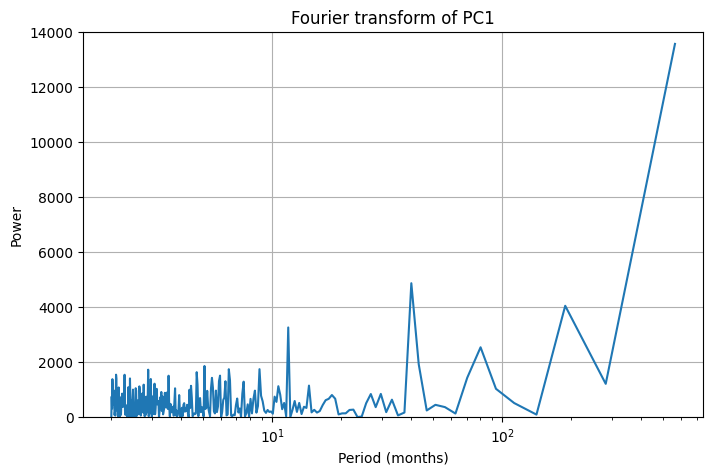

In [53]:
pc1 = pcs[:,1]
# remove mean
x = pc1.values - pc1.values.mean()


fft = np.fft.rfft(x)
power = np.abs(fft)**2

freq = np.fft.rfftfreq(len(x), d=1)

plt.figure(figsize=(8,5))

plt.semilogx(1 / freq[1:], power[1:])   # 

plt.xlabel("Period (months)")
plt.ylim(0,14000)
plt.ylabel("Power")
plt.title("Fourier transform of PC1")
plt.grid()

plt.savefig('darwin-tahiti-pc1.pdf')
plt.show()

In [48]:
freq

array([0.        , 0.00177305, 0.0035461 , 0.00531915, 0.0070922 ,
       0.00886525, 0.0106383 , 0.01241135, 0.0141844 , 0.01595745,
       0.0177305 , 0.01950355, 0.0212766 , 0.02304965, 0.0248227 ,
       0.02659574, 0.02836879, 0.03014184, 0.03191489, 0.03368794,
       0.03546099, 0.03723404, 0.03900709, 0.04078014, 0.04255319,
       0.04432624, 0.04609929, 0.04787234, 0.04964539, 0.05141844,
       0.05319149, 0.05496454, 0.05673759, 0.05851064, 0.06028369,
       0.06205674, 0.06382979, 0.06560284, 0.06737589, 0.06914894,
       0.07092199, 0.07269504, 0.07446809, 0.07624113, 0.07801418,
       0.07978723, 0.08156028, 0.08333333, 0.08510638, 0.08687943,
       0.08865248, 0.09042553, 0.09219858, 0.09397163, 0.09574468,
       0.09751773, 0.09929078, 0.10106383, 0.10283688, 0.10460993,
       0.10638298, 0.10815603, 0.10992908, 0.11170213, 0.11347518,
       0.11524823, 0.11702128, 0.11879433, 0.12056738, 0.12234043,
       0.12411348, 0.12588652, 0.12765957, 0.12943262, 0.13120